# 🌳 Métodos de Fusión y Ensemble Learning — CAP Sleep Database

**Notebook 6 del pipeline.** Se ejecuta **después** de:

1. Análisis exploratorio.
2. Preprocesamiento avanzado.
3. Extracción de características.
4. Clasificación y reducción de dimensionalidad.
5. Validación cruzada.

Reutiliza los CSVs de características (`../data/features/caracteristicas_eeg_3s_standard.csv`)
y los resultados del notebook 5 (`../data/results/validacion_cruzada_completa.csv`)
para comparar **ensembles vs clasificadores individuales** con métricas calculadas
bajo el mismo protocolo.

### Foco exclusivo de este notebook

| Bloque | Técnica |
|--------|---------|
| **Ensemble 1 — Bagging/Agregación** | `RandomForestClassifier` |
| **Ensemble 2 — Voting (hard + soft)** | `VotingClassifier` con LogReg + RF + GaussianNB |
| **Ensemble 3 — Boosting** | `AdaBoostClassifier` |
| **Evaluación** | `StratifiedKFold` (ventana) + `StratifiedGroupKFold` (paciente) |
| **Métricas** | accuracy, precision, recall, F1 (todas macro) |
| **Comparación** | ensembles vs individuales del notebook 5 |

## 1. Introducción

### 1.1 ¿Qué es ensemble learning?

El **aprendizaje por ensambles** (*ensemble learning*) consiste en
combinar varios clasificadores base $\{h_1, h_2, \ldots, h_M\}$ para
producir una predicción agregada $H(x)$ que típicamente generaliza mejor
que cualquiera de sus componentes. La intuición clásica viene del
*condorcet jury theorem*: si cada clasificador acierta con probabilidad
$p > 0.5$ y sus errores son **independientes**, la mayoría agrega
información y el error agregado tiende a cero cuando $M \to \infty$.

En la práctica los errores **no** son independientes, pero la diversidad
parcial entre clasificadores ya es suficiente para reducir error.

### 1.2 Métodos de fusión — taxonomía

Existen tres familias canónicas:

| Familia | Idea | Diversidad viene de | Ejemplos |
|---------|------|---------------------|----------|
| **Bagging** | Entrenar el mismo modelo $M$ veces sobre **muestras bootstrap** distintas; promediar | Variación del conjunto de entrenamiento | Random Forest |
| **Boosting** | Entrenar clasificadores **secuencialmente**, cada uno enfocado en los errores del anterior | Foco adaptativo sobre ejemplos difíciles | AdaBoost, Gradient Boosting |
| **Voting / Stacking** | Entrenar clasificadores **distintos** sobre el mismo dataset; agregar sus votos | Diferencia entre algoritmos | VotingClassifier |

### 1.3 Reducción de sesgo y varianza

El error de predicción se descompone clásicamente como:

$$\text{Error} = \text{Sesgo}^2 + \text{Varianza} + \text{Ruido irreducible}$$

- **Bagging reduce varianza:** entrenar $M$ árboles sobre muestras bootstrap
  y promediar reduce la varianza por un factor cercano a $1/M$ si los
  árboles fuesen independientes. Por eso Random Forest, que añade además
  aleatoriedad en la selección de features por nodo, es tan robusto.
- **Boosting reduce sesgo:** AdaBoost combina muchos **clasificadores
  débiles** (poco mejores que el azar) para construir uno fuerte; cada
  nuevo aprendiz corrige los errores residuales del anterior.
- **Voting reduce ambos** marginalmente: la diversidad entre algoritmos
  reduce la correlación de errores, lo que disminuye varianza; y la
  combinación de perspectivas distintas puede compensar sesgos
  individuales.

### 1.4 ¿Por qué útiles en EEG?

Las señales EEG sufren:

- **Alta variabilidad inter-paciente** — un mismo trastorno produce
  perfiles muy distintos entre individuos.
- **Ruido fisiológico** — artefactos musculares, parpadeos, movimientos,
  variaciones de impedancia.
- **Solapamiento entre clases** — ondas similares pueden corresponder a
  etapas o trastornos diferentes.

En este contexto, los ensembles:

- **Promedian** decisiones de varios modelos → reducen el efecto de
  outliers y ventanas con artefactos.
- **Aprovechan diversidad** de algoritmos → un voting con LR + RF + NB
  captura, simultáneamente, fronteras lineales, no lineales y
  probabilísticas.
- **Manejan alta dimensionalidad** sin selección manual, especialmente
  Random Forest (selección aleatoria de features por nodo).

### 1.5 Limitaciones de ensemble learning en EEG

- **No corrigen problemas de etiqueta.** Si las etiquetas son a nivel
  paciente (como aquí) y la variabilidad intra-paciente es alta, ningún
  ensemble inventa información que no existe.
- **No corrigen leakage.** Si la validación admite fuga (CV-A), un
  ensemble puede memorizar al paciente igual que un modelo individual.
- **AdaBoost es sensible a ruido.** Pondera más los ejemplos difíciles,
  pero si esos ejemplos son ruido (artefactos EEG), los amplifica.
- **Coste computacional alto** — 100+ árboles × cientos de miles de
  ventanas no es trivial.
- **Interpretabilidad reducida** — un voto entre 3 modelos o 200 árboles
  es difícil de explicar a un clínico.

### 1.6 Dimensionalidad y ensembles

| Reducción | Beneficio para ensembles |
|---|---|
| **Original (30D)** | Random Forest funciona bien; AdaBoost también |
| **PCA** | Acelera todos; pierde marginal en F1 |
| **Kernel PCA** | Útil si hay no linealidades; coste alto en memoria |
| **SelectKBest** | Reduce dimensionalidad y mantiene interpretabilidad de features |

Random Forest no requiere reducción explícita (ya selecciona features
aleatoriamente por nodo), pero PCA o SelectKBest pueden acelerar el
entrenamiento sin perder F1.

## 2. Importaciones

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Clasificadores base
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, AdaBoostClassifier,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Validación cruzada
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold, cross_validate,
    train_test_split,
)

# Reducción de dimensionalidad
from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import SelectKBest, f_classif

# Pipelines y métricas
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer,
)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
K_FOLDS = 5
print(f'Random state global : {RANDOM_STATE}')
print(f'Folds (k)           : {K_FOLDS}')

Random state global : 42
Folds (k)           : 5


## 3. Carga de datasets

Reutilizamos las características estandarizadas del notebook 3 y los
resultados de CV del notebook 5 (para comparar ensembles vs individuales).

> **"3 datasets" del enunciado original:** trabajamos sobre subcohortes
> de la CAP Sleep Database — `brux1`, `ins1` y `narco1` y sus equivalentes
> de la misma patología — tratados como tres orígenes de datos.

In [2]:
FEATURES_DIR = Path.cwd() / '../data/features'
RESULTS_DIR  = Path.cwd() / '../data/results'
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

def cargar_csv(directorio, nombre):
    ruta = directorio / nombre
    if not ruta.exists():
        raise FileNotFoundError(f'No se encontró {ruta}')
    return pd.read_csv(ruta)

# Dataset principal
df = cargar_csv(FEATURES_DIR, 'caracteristicas_eeg_3s_standard.csv')

# Resultados previos (opcional, para comparación con individuales)
try:
    cv_previo = cargar_csv(RESULTS_DIR, 'validacion_cruzada_completa.csv')
    print(f'Resultados de validación cruzada previos: {cv_previo.shape}')
except FileNotFoundError:
    cv_previo = None
    print('⚠️  validacion_cruzada_completa.csv no encontrado — '
          'la comparación contra individuales se omitirá.')

print(f'\nDataset de características : {df.shape}')
print(f'Total ventanas              : {len(df):,}')
print(f'Pacientes únicos            : {df["patient"].nunique()}')
print(f'Clases (disorder)           : {df["disorder"].nunique()}')

print('\nDistribución de clases (ventanas):')
print(df['disorder'].value_counts().to_string())

Resultados de validación cruzada previos: (120, 8)

Dataset de características : (656930, 36)
Total ventanas              : 656,930
Pacientes únicos            : 8
Clases (disorder)           : 8

Distribución de clases (ventanas):
disorder
Epilepsia nocturna frontal    141440
Movimientos periódicos        118440
Normal                         80780
Insomnio                       80000
Trastorno REM                  70630
Bruxismo                       62140
Narcolepsia                    56400
Trastorno respiratorio         47100


## 4. Preparación de datos

Mismo esquema de los notebooks anteriores: separamos `X`, `y`, `groups`
y descartamos columnas de metadata.

In [3]:
COLS_META = ['patient', 'disorder', 'channel', 'ch_category',
             'window_idx', 'onset_s']
CARACT_COLS = [c for c in df.columns if c not in COLS_META]

X = df[CARACT_COLS].copy()
y = df['disorder'].copy()
groups = df['patient'].copy()

# Validaciones
print(f'Dimensión de X      : {X.shape}')
print(f'NaN en X            : {X.isna().sum().sum()}')
print(f'Infinitos en X      : {np.isinf(X.values).sum()}')

std_por_col = X.std()
constantes = std_por_col[std_por_col == 0].index.tolist()
if constantes:
    X = X.drop(columns=constantes)
    CARACT_COLS = [c for c in CARACT_COLS if c not in constantes]
    print(f'  → Eliminadas columnas constantes: {constantes}')

if X.isna().sum().sum() > 0:
    X = X.fillna(X.median())
    print('  → Imputado NaN con mediana')

print(f'\nFeatures finales    : {len(CARACT_COLS)}')
print(f'Clases distintas    : {sorted(y.unique())}')
print(f'Pacientes en groups : {groups.nunique()}')

Dimensión de X      : (656930, 30)
NaN en X            : 0
Infinitos en X      : 0

Features finales    : 30
Clases distintas    : ['Bruxismo', 'Epilepsia nocturna frontal', 'Insomnio', 'Movimientos periódicos', 'Narcolepsia', 'Normal', 'Trastorno REM', 'Trastorno respiratorio']
Pacientes en groups : 8


### 4.1 Sobre las etiquetas

Como se discutió en notebooks anteriores, cada paciente trae una etiqueta
clínica única (su trastorno). Todas las ventanas heredan esa etiqueta, lo
que tiene implicaciones para los ensembles:

- Un ensemble entrenado bajo CV-A (nivel ventana) **memoriza al paciente**
  igual que un modelo individual — porque sus árboles ven ventanas del
  mismo paciente.
- Bajo CV-B (por paciente), el ensemble enfrenta el mismo problema de
  generalización inter-paciente que los individuales. La pregunta
  honesta es: **¿qué tanto del beneficio del ensemble persiste cuando se
  evalúa correctamente?**

## 5. Configuración de validación cruzada

Replicamos exactamente la estrategia del notebook 5 para que las métricas
sean **directamente comparables** con los clasificadores individuales:

- `StratifiedKFold(k=5)` — CV-A, nivel ventana, optimista.
- `StratifiedGroupKFold(k=5)` — CV-B, por paciente, realista.
- `shuffle=True`, `random_state=42`.

In [4]:
cv_window  = StratifiedKFold(n_splits=K_FOLDS, shuffle=True,
                              random_state=RANDOM_STATE)
cv_patient = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                                   random_state=RANDOM_STATE)

SCORING = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall':    make_scorer(recall_score,    average='macro', zero_division=0),
    'f1':        make_scorer(f1_score,        average='macro', zero_division=0),
}

# Verificación: pacientes en cada fold de CV-B
print('CV-B (por paciente) — composición de folds:')
for i, (tr_idx, te_idx) in enumerate(cv_patient.split(X, y, groups), 1):
    pac_test = sorted(groups.iloc[te_idx].unique())
    n_clases_te = y.iloc[te_idx].nunique()
    print(f'  Fold {i}: {len(te_idx):>6,} ventanas, '
          f'{n_clases_te} clases, pacientes={pac_test}')

CV-B (por paciente) — composición de folds:
  Fold 1: 118,440 ventanas, 1 clases, pacientes=['plm1']
  Fold 2: 127,880 ventanas, 2 clases, pacientes=['n1', 'sdb1']
  Fold 3: 136,400 ventanas, 2 clases, pacientes=['ins1', 'narco1']
  Fold 4: 141,440 ventanas, 1 clases, pacientes=['nfle1']
  Fold 5: 132,770 ventanas, 2 clases, pacientes=['brux1', 'rbd1']


## 6. Método 1: Random Forest (Bagging/Agregación)

### 6.1 Fundamento matemático del bagging

**Bagging** (*Bootstrap AGGregatING*, Breiman 1996) construye $M$
clasificadores $\{h_m\}_{m=1}^M$ entrenando cada uno sobre una muestra
**bootstrap** $\mathcal{D}_m$ del conjunto de entrenamiento — es decir,
$n$ ejemplos muestreados con reemplazo. La predicción agregada es la
moda (clasificación) o promedio (regresión):

$$H(x) = \text{mode}\{h_1(x), h_2(x), \ldots, h_M(x)\}$$

#### ¿Por qué reduce varianza?

Si los $h_m$ fuesen i.i.d. con varianza $\sigma^2$, la varianza del
promedio sería $\sigma^2/M$. En la práctica los árboles están
correlacionados ($\rho > 0$), por lo que:

$$\text{Var}(\bar{H}) = \rho \sigma^2 + \frac{(1-\rho) \sigma^2}{M}$$

El primer término no disminuye con $M$; por eso Random Forest añade un
segundo nivel de aleatoriedad: **en cada nodo, considera solo
$\sqrt{p}$ features al azar** (con $p$ = total). Esto **decorrelaciona**
los árboles, reduciendo $\rho$ y por tanto la varianza agregada.

### 6.2 Robustez del Random Forest

- **Maneja alta dimensionalidad** sin selección previa.
- **Insensible al escalado** (las particiones de árbol son invariantes
  a transformaciones monotónicas).
- **Robusto a outliers** en features (los árboles los aíslan en hojas
  separadas).
- **Sensible a desbalance** — mitigado con `class_weight='balanced'`.
- **Tolerante al ruido EEG** porque promedia muchos árboles.

### 6.3 Parámetros usados

Mismos del notebook 5 para que la métrica del Random Forest sea
comparable con la registrada allí.

In [5]:
def correr_cv_modelo(modelo, etiqueta_estrategia, cv_obj,
                     groups_data=None, etiqueta_ensemble='Modelo'):
    '''
    Aplica validación cruzada a un modelo y devuelve registros con
    accuracy, precision, recall, F1 por fold.
    '''
    cv_kwargs = dict(cv=cv_obj, scoring=SCORING,
                     return_train_score=False, n_jobs=-1)
    if groups_data is not None:
        res = cross_validate(modelo, X, y, groups=groups_data, **cv_kwargs)
    else:
        res = cross_validate(modelo, X, y, **cv_kwargs)

    registros = []
    for fold, (acc, prec, rec, f1) in enumerate(zip(
        res['test_accuracy'], res['test_precision'],
        res['test_recall'],   res['test_f1']
    ), 1):
        registros.append({
            'estrategia': etiqueta_estrategia,
            'ensemble':   etiqueta_ensemble,
            'fold':       fold,
            'accuracy':   acc, 'precision': prec,
            'recall':     rec, 'f1':        f1,
        })
    return pd.DataFrame(registros)


# ── Definir Random Forest ──
rf_ensemble = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Ensemble 1 — Random Forest (Bagging)')
print('=' * 55)

print('\n[CV-A: nivel ventana]')
rf_resA = correr_cv_modelo(rf_ensemble, 'CV-A: Ventana', cv_window,
                            etiqueta_ensemble='Random Forest (bagging)')
print(rf_resA.set_index('fold')[['accuracy', 'precision',
                                  'recall', 'f1']].round(4).to_string())

print('\n[CV-B: por paciente]')
rf_resB = correr_cv_modelo(rf_ensemble, 'CV-B: Paciente', cv_patient,
                            groups_data=groups,
                            etiqueta_ensemble='Random Forest (bagging)')
print(rf_resB.set_index('fold')[['accuracy', 'precision',
                                  'recall', 'f1']].round(4).to_string())

Ensemble 1 — Random Forest (Bagging)

[CV-A: nivel ventana]
      accuracy  precision  recall      f1
fold                                     
1       0.6770     0.6837  0.6660  0.6688
2       0.6775     0.6841  0.6654  0.6685
3       0.6773     0.6835  0.6654  0.6685
4       0.6793     0.6865  0.6685  0.6715
5       0.6796     0.6840  0.6679  0.6704

[CV-B: por paciente]
      accuracy  precision  recall   f1
fold                                  
1          0.0        0.0     0.0  0.0
2          0.0        0.0     0.0  0.0
3          0.0        0.0     0.0  0.0
4          0.0        0.0     0.0  0.0
5          0.0        0.0     0.0  0.0


In [6]:
# Resumen Random Forest
for nombre_estrategia, res in [('CV-A', rf_resA), ('CV-B', rf_resB)]:
    print(f'\nRandom Forest — {nombre_estrategia}: '
          f'F1 = {res["f1"].mean():.4f} ± {res["f1"].std():.4f}  '
          f'(min={res["f1"].min():.4f}, max={res["f1"].max():.4f})')


Random Forest — CV-A: F1 = 0.6696 ± 0.0014  (min=0.6685, max=0.6715)

Random Forest — CV-B: F1 = 0.0000 ± 0.0000  (min=0.0000, max=0.0000)


## 7. Método 2: Voting con clasificadores heterogéneos

### 7.1 Lógica de votación

`VotingClassifier` combina $M$ clasificadores **distintos**
$\{h_1, \ldots, h_M\}$ entrenados sobre **el mismo dataset**. Hay dos
modos:

#### Hard voting

$$H(x) = \text{mode}\{h_1(x), h_2(x), \ldots, h_M(x)\}$$

Cada clasificador emite un voto categórico y se elige la clase más votada.
Si hay empate, se elige la clase con menor índice (sklearn).

#### Soft voting

$$H(x) = \arg\max_c \sum_{m=1}^{M} P_m(y = c \mid x)$$

Cada clasificador emite una **probabilidad** y se promedia. Suele ser
mejor que hard voting si los clasificadores están bien calibrados.

### 7.2 Importancia de la diversidad

El voting funciona cuando los clasificadores tienen **errores poco
correlacionados**. Si todos cometen exactamente los mismos errores, votar
no aporta nada. Por eso elegimos algoritmos con sesgos inductivos
distintos:

| Clasificador | Sesgo / Familia | Aporta |
|---|---|---|
| **LogisticRegression** | Lineal, probabilístico | Frontera lineal suave |
| **RandomForestClassifier** | No lineal, basado en árboles | Captura interacciones y no linealidades |
| **GaussianNB** | Probabilístico generativo, asume independencia | Estimación rápida, manejo natural de incertidumbre |

Estos tres tienen **fronteras de decisión distintas** sobre el mismo
dataset, lo que maximiza la diversidad y permite que el voto agregado
sea más robusto que cualquiera individual.

### 7.3 Modelo lineal, modelo basado en árboles y modelo probabilístico

- **LogReg** modela $P(y|x) \propto \exp(w^\top x)$ → frontera **lineal**.
- **Random Forest** particiona el espacio en hipercubos → frontera
  **no lineal escalonada**.
- **GaussianNB** asume features condicionalmente independientes dada la
  clase, con verosimilitudes gaussianas → frontera **cuadrática**.

Esto convierte al VotingClassifier en un ensamble **realmente diverso**,
a diferencia de un ensemble homogéneo (bagging de un solo tipo de
modelo).

In [7]:
# ── Definir clasificadores base ──
clf_lr = LogisticRegression(
    max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE,
)
clf_rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_STATE,
)
clf_nb = GaussianNB()

# ── Hard voting ──
voting_hard = VotingClassifier(
    estimators=[
        ('lr', clf_lr),
        ('rf', clf_rf),
        ('nb', clf_nb),
    ],
    voting='hard',
    n_jobs=-1,
)

# ── Soft voting ──
voting_soft = VotingClassifier(
    estimators=[
        ('lr', clf_lr),
        ('rf', clf_rf),
        ('nb', clf_nb),
    ],
    voting='soft',
    n_jobs=-1,
)

print('Ensemble 2 — VotingClassifier (LR + RF + GaussianNB)')
print('=' * 55)

print('\n[Hard voting — CV-A]')
vh_resA = correr_cv_modelo(voting_hard, 'CV-A: Ventana', cv_window,
                            etiqueta_ensemble='Voting (hard)')
print(vh_resA.set_index('fold')[['accuracy', 'precision',
                                   'recall', 'f1']].round(4).to_string())

print('\n[Hard voting — CV-B]')
vh_resB = correr_cv_modelo(voting_hard, 'CV-B: Paciente', cv_patient,
                            groups_data=groups,
                            etiqueta_ensemble='Voting (hard)')
print(vh_resB.set_index('fold')[['accuracy', 'precision',
                                   'recall', 'f1']].round(4).to_string())

Ensemble 2 — VotingClassifier (LR + RF + GaussianNB)

[Hard voting — CV-A]
      accuracy  precision  recall      f1
fold                                     
1       0.5359     0.5807  0.5159  0.5084
2       0.5359     0.5839  0.5140  0.5077
3       0.5382     0.5773  0.5171  0.5100
4       0.5403     0.5786  0.5211  0.5157
5       0.5317     0.5735  0.5081  0.5034

[Hard voting — CV-B]
      accuracy  precision  recall   f1
fold                                  
1          0.0        0.0     0.0  0.0
2          0.0        0.0     0.0  0.0
3          0.0        0.0     0.0  0.0
4          0.0        0.0     0.0  0.0
5          0.0        0.0     0.0  0.0


In [8]:
print('\n[Soft voting — CV-A]')
vs_resA = correr_cv_modelo(voting_soft, 'CV-A: Ventana', cv_window,
                            etiqueta_ensemble='Voting (soft)')
print(vs_resA.set_index('fold')[['accuracy', 'precision',
                                   'recall', 'f1']].round(4).to_string())

print('\n[Soft voting — CV-B]')
vs_resB = correr_cv_modelo(voting_soft, 'CV-B: Paciente', cv_patient,
                            groups_data=groups,
                            etiqueta_ensemble='Voting (soft)')
print(vs_resB.set_index('fold')[['accuracy', 'precision',
                                   'recall', 'f1']].round(4).to_string())

# Resumen Voting
print('\n' + '=' * 55)
for nombre, res in [('Hard - CV-A', vh_resA), ('Hard - CV-B', vh_resB),
                     ('Soft - CV-A', vs_resA), ('Soft - CV-B', vs_resB)]:
    print(f'Voting {nombre}: F1 = {res["f1"].mean():.4f} ± {res["f1"].std():.4f}')


[Soft voting — CV-A]
      accuracy  precision  recall      f1
fold                                     
1       0.4027     0.5974  0.4247  0.4163
2       0.3962     0.6016  0.4163  0.4088
3       0.4043     0.5941  0.4261  0.4196
4       0.4030     0.5888  0.4262  0.4225
5       0.4147     0.5829  0.4269  0.4291

[Soft voting — CV-B]
      accuracy  precision  recall   f1
fold                                  
1          0.0        0.0     0.0  0.0
2          0.0        0.0     0.0  0.0
3          0.0        0.0     0.0  0.0
4          0.0        0.0     0.0  0.0
5          0.0        0.0     0.0  0.0

Voting Hard - CV-A: F1 = 0.5091 ± 0.0044
Voting Hard - CV-B: F1 = 0.0000 ± 0.0000
Voting Soft - CV-A: F1 = 0.4193 ± 0.0075
Voting Soft - CV-B: F1 = 0.0000 ± 0.0000


## 8. Método 3: AdaBoost

### 8.1 Fundamento matemático del boosting

**AdaBoost** (*Adaptive Boosting*, Freund & Schapire 1995) entrena
clasificadores **secuencialmente**, cada uno enfocándose en los errores
del anterior. Algoritmo (binario clásico; sklearn usa SAMME para
multiclase):

1. Inicializar pesos uniformes: $w_i^{(1)} = 1/n$ para todo ejemplo $i$.
2. Para $m = 1, \ldots, M$:
   a. Entrenar $h_m$ minimizando error ponderado.
   b. Calcular error: $\epsilon_m = \sum_i w_i^{(m)} \mathbb{1}[h_m(x_i) \neq y_i]$.
   c. Peso del clasificador: $\alpha_m = \frac{1}{2} \ln \frac{1 - \epsilon_m}{\epsilon_m}$.
   d. Actualizar pesos: $w_i^{(m+1)} \propto w_i^{(m)} \cdot \exp(-\alpha_m y_i h_m(x_i))$.
3. Predicción final:

$$H(x) = \text{sign}\left(\sum_{m=1}^{M} \alpha_m h_m(x)\right)$$

Cada **clasificador débil** (típicamente un *decision stump*: árbol de
profundidad 1) aporta poco aisladamente, pero su combinación ponderada
puede ser muy potente.

### 8.2 Aprendizaje secuencial y pesos adaptativos

El elemento clave es la **actualización de pesos**: ejemplos mal
clasificados reciben más peso en la siguiente iteración. Esto fuerza al
siguiente clasificador a "prestar atención" a los casos difíciles que
los anteriores no resolvieron.

### 8.3 Sensibilidad al ruido EEG

AdaBoost tiene una propiedad doble:

✅ **Ventaja:** logra reducir sesgo significativamente combinando muchos
clasificadores débiles.

⚠️ **Desventaja:** **es sensible a outliers y ruido**. Si una ventana EEG
es un artefacto puro, será mal clasificada por casi todos los
clasificadores → su peso se disparará → AdaBoost dedicará iteraciones a
"aprenderla", pero como no es señal real, solo añade overfitting.

En EEG con artefactos residuales, esto puede degradar el desempeño en
test, especialmente bajo CV-B.

### 8.4 Importancia de los estimadores débiles

El estimador base de AdaBoost debe ser:

- **Débil pero ligeramente mejor que el azar** — accuracy > $1/C$ donde
  $C$ es el número de clases.
- **Rápido de entrenar** — porque se entrenará $M$ veces.

El default en sklearn es un `DecisionTreeClassifier(max_depth=1)`. Lo
mantenemos para reflejar el uso canónico de AdaBoost.

In [9]:
# AdaBoost con estimadores débiles (decision stumps)
ada_ensemble = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1, random_state=RANDOM_STATE,
    ),
    n_estimators=100,
    learning_rate=1.0,
    random_state=RANDOM_STATE,
)

print('Ensemble 3 — AdaBoost (Boosting)')
print('=' * 55)

print('\n[CV-A: nivel ventana]')
ada_resA = correr_cv_modelo(ada_ensemble, 'CV-A: Ventana', cv_window,
                             etiqueta_ensemble='AdaBoost')
print(ada_resA.set_index('fold')[['accuracy', 'precision',
                                    'recall', 'f1']].round(4).to_string())

print('\n[CV-B: por paciente]')
ada_resB = correr_cv_modelo(ada_ensemble, 'CV-B: Paciente', cv_patient,
                             groups_data=groups,
                             etiqueta_ensemble='AdaBoost')
print(ada_resB.set_index('fold')[['accuracy', 'precision',
                                    'recall', 'f1']].round(4).to_string())

print(f'\nAdaBoost CV-A: F1 = {ada_resA["f1"].mean():.4f} ± {ada_resA["f1"].std():.4f}')
print(f'AdaBoost CV-B: F1 = {ada_resB["f1"].mean():.4f} ± {ada_resB["f1"].std():.4f}')

Ensemble 3 — AdaBoost (Boosting)

[CV-A: nivel ventana]
      accuracy  precision  recall      f1
fold                                     
1       0.3811     0.3536  0.3540  0.3319
2       0.4043     0.3992  0.3787  0.3695
3       0.3745     0.3803  0.3319  0.3216
4       0.3993     0.3831  0.3751  0.3594
5       0.3686     0.3476  0.3303  0.3127

[CV-B: por paciente]
      accuracy  precision  recall   f1
fold                                  
1          0.0        0.0     0.0  0.0
2          0.0        0.0     0.0  0.0
3          0.0        0.0     0.0  0.0
4          0.0        0.0     0.0  0.0
5          0.0        0.0     0.0  0.0

AdaBoost CV-A: F1 = 0.3390 ± 0.0244
AdaBoost CV-B: F1 = 0.0000 ± 0.0000


## 9. Comparación de los tres métodos de fusión

Consolidamos las mediciones de los cuatro ensembles (RF, Voting hard,
Voting soft, AdaBoost) en CV-A y CV-B, junto con los clasificadores
individuales del notebook 5 cuando estén disponibles.

In [10]:
# Consolidar resultados de ensembles
df_ensembles = pd.concat([
    rf_resA, rf_resB,
    vh_resA, vh_resB,
    vs_resA, vs_resB,
    ada_resA, ada_resB,
], ignore_index=True)

print(f'Total mediciones de ensembles: {len(df_ensembles)}')
print(f'  (4 ensembles × 2 estrategias × {K_FOLDS} folds)')

Total mediciones de ensembles: 40
  (4 ensembles × 2 estrategias × 5 folds)


In [11]:
# Tabla resumen
def tabla_resumen(df, value='f1', col='ensemble'):
    agg = df.groupby(['estrategia', col])[value].agg(['mean', 'std'])
    agg['cell'] = agg.apply(
        lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
    )
    return agg['cell'].unstack(level=col)


print('═══ F1 macro promedio ± desviación (4 ensembles × 2 estrategias) ═══\n')
print(tabla_resumen(df_ensembles, 'f1').to_string())

print('\n═══ Accuracy promedio ± desviación ═══\n')
print(tabla_resumen(df_ensembles, 'accuracy').to_string())

═══ F1 macro promedio ± desviación (4 ensembles × 2 estrategias) ═══

ensemble             AdaBoost Random Forest (bagging)  Voting (hard)  Voting (soft)
estrategia                                                                         
CV-A: Ventana   0.339 ± 0.024           0.670 ± 0.001  0.509 ± 0.004  0.419 ± 0.008
CV-B: Paciente  0.000 ± 0.000           0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000

═══ Accuracy promedio ± desviación ═══

ensemble             AdaBoost Random Forest (bagging)  Voting (hard)  Voting (soft)
estrategia                                                                         
CV-A: Ventana   0.386 ± 0.016           0.678 ± 0.001  0.536 ± 0.003  0.404 ± 0.007
CV-B: Paciente  0.000 ± 0.000           0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000


In [12]:
# Comparación con clasificadores individuales del notebook 5
if cv_previo is not None:
    # Filtrar solo configuración "Original" del notebook 5 (sin reducción)
    individuales = cv_previo[cv_previo['reduccion'] == 'Original'].copy()
    individuales['ensemble'] = individuales['modelo'] + ' (individual)'
    individuales = individuales[['estrategia', 'ensemble', 'fold',
                                  'accuracy', 'precision', 'recall', 'f1']]

    # Concatenar para comparación
    df_comparacion = pd.concat([df_ensembles, individuales],
                                ignore_index=True)

    print('═══ Ensembles vs Individuales (F1 macro) ═══\n')
    print(tabla_resumen(df_comparacion, 'f1').to_string())
else:
    df_comparacion = df_ensembles.copy()
    print('⚠️  No se cargaron resultados del notebook 5; '
          'la comparación con individuales se omite.')

═══ Ensembles vs Individuales (F1 macro) ═══

ensemble             AdaBoost Perceptrón (individual) Random Forest (bagging) Random Forest (individual) Regresión Logística (individual)  Voting (hard)  Voting (soft)
estrategia                                                                                                                                                             
CV-A: Ventana   0.339 ± 0.024           0.291 ± 0.044           0.670 ± 0.001              0.670 ± 0.001                    0.413 ± 0.001  0.509 ± 0.004  0.419 ± 0.008
CV-B: Paciente  0.000 ± 0.000           0.000 ± 0.000           0.000 ± 0.000              0.000 ± 0.000                    0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000


## 10. Resultados por fold

Detalle de cada fold para detectar variabilidad y folds problemáticos.

In [13]:
# Pivot por fold y ensemble en CV-B (la estrategia clínicamente correcta)
df_cvB = df_ensembles[df_ensembles['estrategia'] == 'CV-B: Paciente'].copy()

print('═══ F1 macro por fold — CV-B (por paciente) ═══\n')
pivot_fold = df_cvB.pivot_table(
    index='ensemble', columns='fold', values='f1', aggfunc='first',
).round(4)
pivot_fold['media'] = pivot_fold.mean(axis=1).round(4)
pivot_fold['std']   = df_cvB.groupby('ensemble')['f1'].std().round(4).values
pivot_fold['cv_%']  = (pivot_fold['std'] / pivot_fold['media'].abs() * 100).round(1)
print(pivot_fold.to_string())

═══ F1 macro por fold — CV-B (por paciente) ═══

fold                       1    2    3    4    5  media  std  cv_%
ensemble                                                          
AdaBoost                 0.0  0.0  0.0  0.0  0.0    0.0  0.0   NaN
Random Forest (bagging)  0.0  0.0  0.0  0.0  0.0    0.0  0.0   NaN
Voting (hard)            0.0  0.0  0.0  0.0  0.0    0.0  0.0   NaN
Voting (soft)            0.0  0.0  0.0  0.0  0.0    0.0  0.0   NaN


In [14]:
# Identificar folds problemáticos en CV-B
fold_means = df_cvB.groupby('fold')['f1'].agg(['mean', 'std']).round(4)
print('F1 promedio por fold (CV-B, agregado entre ensembles):')
print(fold_means.to_string())

peor_fold = fold_means['mean'].idxmin()
splits = list(cv_patient.split(X, y, groups))
_, te_idx_peor = splits[peor_fold - 1]
pac_peor = sorted(groups.iloc[te_idx_peor].unique())
clases_peor = sorted(y.iloc[te_idx_peor].unique())

print(f'\nFold con peor F1 promedio: Fold {peor_fold} '
      f'(F1 medio = {fold_means.loc[peor_fold, "mean"]:.3f})')
print(f'  Pacientes en este fold: {pac_peor}')
print(f'  Clases representadas  : {clases_peor}')
print(f'  Cuando un fold contiene pocos pacientes o pocas clases distintas,')
print(f'  los ensembles tienen poco margen de mejora sobre el azar.')

F1 promedio por fold (CV-B, agregado entre ensembles):
      mean  std
fold           
1      0.0  0.0
2      0.0  0.0
3      0.0  0.0
4      0.0  0.0
5      0.0  0.0

Fold con peor F1 promedio: Fold 1 (F1 medio = 0.000)
  Pacientes en este fold: ['plm1']
  Clases representadas  : ['Movimientos periódicos']
  Cuando un fold contiene pocos pacientes o pocas clases distintas,
  los ensembles tienen poco margen de mejora sobre el azar.


## 11. Ensembles con reducción de dimensionalidad

Evaluamos los cuatro ensembles con tres variantes de reducción usando
`Pipeline` para evitar fugas de información entre folds:

| Variante | Pipeline |
|---|---|
| Original (~30D) | sin reducción |
| PCA | PCA(95 % var) → ensemble |
| SelectKBest | SelectKBest(top 10) → ensemble |

Kernel PCA se omite aquí por su coste $O(n^2)$ y porque ya fue evaluado
en el notebook 5; sus conclusiones se mantienen para los ensembles.

In [15]:
K_BEST = 10

def make_pipe(reductor, modelo):
    pasos = []
    if reductor is not None:
        pasos.append(('red', reductor))
    pasos.append(('clf', modelo))
    return Pipeline(pasos)


def correr_cv_pipeline(pipe, etiqueta_estrategia, cv_obj,
                       groups_data=None, etiqueta_ensemble='',
                       etiqueta_reduccion=''):
    cv_kwargs = dict(cv=cv_obj, scoring=SCORING,
                     return_train_score=False, n_jobs=-1)
    if groups_data is not None:
        res = cross_validate(pipe, X, y, groups=groups_data, **cv_kwargs)
    else:
        res = cross_validate(pipe, X, y, **cv_kwargs)

    registros = []
    for fold, (acc, prec, rec, f1) in enumerate(zip(
        res['test_accuracy'], res['test_precision'],
        res['test_recall'],   res['test_f1']
    ), 1):
        registros.append({
            'estrategia': etiqueta_estrategia,
            'ensemble':   etiqueta_ensemble,
            'reduccion':  etiqueta_reduccion,
            'fold':       fold,
            'accuracy':   acc, 'precision': prec,
            'recall':     rec, 'f1':        f1,
        })
    return pd.DataFrame(registros)


def construir_ensembles():
    '''Devuelve un dict {nombre: instancia} de los 4 ensembles.'''
    return {
        'Random Forest (bagging)': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE,
        ),
        'Voting (hard)': VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=2000, solver='lbfgs',
                                          random_state=RANDOM_STATE)),
                ('rf', RandomForestClassifier(n_estimators=100,
                                              class_weight='balanced',
                                              n_jobs=-1,
                                              random_state=RANDOM_STATE)),
                ('nb', GaussianNB()),
            ], voting='hard', n_jobs=-1,
        ),
        'Voting (soft)': VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=2000, solver='lbfgs',
                                          random_state=RANDOM_STATE)),
                ('rf', RandomForestClassifier(n_estimators=100,
                                              class_weight='balanced',
                                              n_jobs=-1,
                                              random_state=RANDOM_STATE)),
                ('nb', GaussianNB()),
            ], voting='soft', n_jobs=-1,
        ),
        'AdaBoost': AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1,
                                              random_state=RANDOM_STATE),
            n_estimators=100, learning_rate=1.0,
            random_state=RANDOM_STATE,
        ),
    }


REDUCTORES = {
    'Original (~30D)': None,
    f'PCA (~95% var)': PCA(n_components=0.95, random_state=RANDOM_STATE),
    f'SelectKBest (top {K_BEST})': SelectKBest(score_func=f_classif, k=K_BEST),
}

print('Definidos:')
print(f'  Ensembles : {list(construir_ensembles().keys())}')
print(f'  Reductores: {list(REDUCTORES.keys())}')

Definidos:
  Ensembles : ['Random Forest (bagging)', 'Voting (hard)', 'Voting (soft)', 'AdaBoost']
  Reductores: ['Original (~30D)', 'PCA (~95% var)', 'SelectKBest (top 10)']


In [16]:
# Ejecutar todas las combinaciones — esto puede tardar varios minutos
registros = []
total = len(construir_ensembles()) * len(REDUCTORES) * 2
hecho = 0

for nombre_red, reductor in REDUCTORES.items():
    for nombre_ens, ens in construir_ensembles().items():
        # CV-A
        pipe = make_pipe(reductor, ens)
        registros.append(correr_cv_pipeline(
            pipe, 'CV-A: Ventana', cv_window,
            etiqueta_ensemble=nombre_ens,
            etiqueta_reduccion=nombre_red,
        ))
        hecho += 1
        print(f'  [{hecho}/{total}] CV-A | {nombre_ens} | {nombre_red}')

        # CV-B
        pipe = make_pipe(reductor, ens)
        registros.append(correr_cv_pipeline(
            pipe, 'CV-B: Paciente', cv_patient, groups_data=groups,
            etiqueta_ensemble=nombre_ens,
            etiqueta_reduccion=nombre_red,
        ))
        hecho += 1
        print(f'  [{hecho}/{total}] CV-B | {nombre_ens} | {nombre_red}')

df_full = pd.concat(registros, ignore_index=True)
print(f'\nMediciones totales: {len(df_full)} '
      f'(= 4 ensembles × {len(REDUCTORES)} reducciones × 2 estrategias × {K_FOLDS} folds)')

  [1/24] CV-A | Random Forest (bagging) | Original (~30D)
  [2/24] CV-B | Random Forest (bagging) | Original (~30D)
  [3/24] CV-A | Voting (hard) | Original (~30D)
  [4/24] CV-B | Voting (hard) | Original (~30D)
  [5/24] CV-A | Voting (soft) | Original (~30D)
  [6/24] CV-B | Voting (soft) | Original (~30D)
  [7/24] CV-A | AdaBoost | Original (~30D)
  [8/24] CV-B | AdaBoost | Original (~30D)
  [9/24] CV-A | Random Forest (bagging) | PCA (~95% var)
  [10/24] CV-B | Random Forest (bagging) | PCA (~95% var)
  [11/24] CV-A | Voting (hard) | PCA (~95% var)
  [12/24] CV-B | Voting (hard) | PCA (~95% var)
  [13/24] CV-A | Voting (soft) | PCA (~95% var)
  [14/24] CV-B | Voting (soft) | PCA (~95% var)
  [15/24] CV-A | AdaBoost | PCA (~95% var)
  [16/24] CV-B | AdaBoost | PCA (~95% var)
  [17/24] CV-A | Random Forest (bagging) | SelectKBest (top 10)
  [18/24] CV-B | Random Forest (bagging) | SelectKBest (top 10)
  [19/24] CV-A | Voting (hard) | SelectKBest (top 10)
  [20/24] CV-B | Voting (hard) 

In [17]:
# Tabla resumen F1 por estrategia × reducción × ensemble
print('═══ F1 macro promedio — ensembles × reducciones × estrategia ═══\n')
resumen_red = df_full.pivot_table(
    index=['estrategia', 'reduccion'], columns='ensemble',
    values='f1', aggfunc='mean',
).round(4)
print(resumen_red.to_string())

═══ F1 macro promedio — ensembles × reducciones × estrategia ═══

ensemble                             AdaBoost  Random Forest (bagging)  Voting (hard)  Voting (soft)
estrategia     reduccion                                                                            
CV-A: Ventana  Original (~30D)         0.3390                   0.6696         0.5091         0.4193
               PCA (~95% var)          0.3234                   0.5634         0.4360         0.4233
               SelectKBest (top 10)    0.3145                   0.4702         0.3848         0.3486
CV-B: Paciente Original (~30D)         0.0000                   0.0000         0.0000         0.0000
               PCA (~95% var)          0.0000                   0.0000         0.0000         0.0000
               SelectKBest (top 10)    0.0000                   0.0000         0.0000         0.0000


## 12. Visualizaciones

### 12.1 Boxplots: F1 por ensemble en CV-A y CV-B

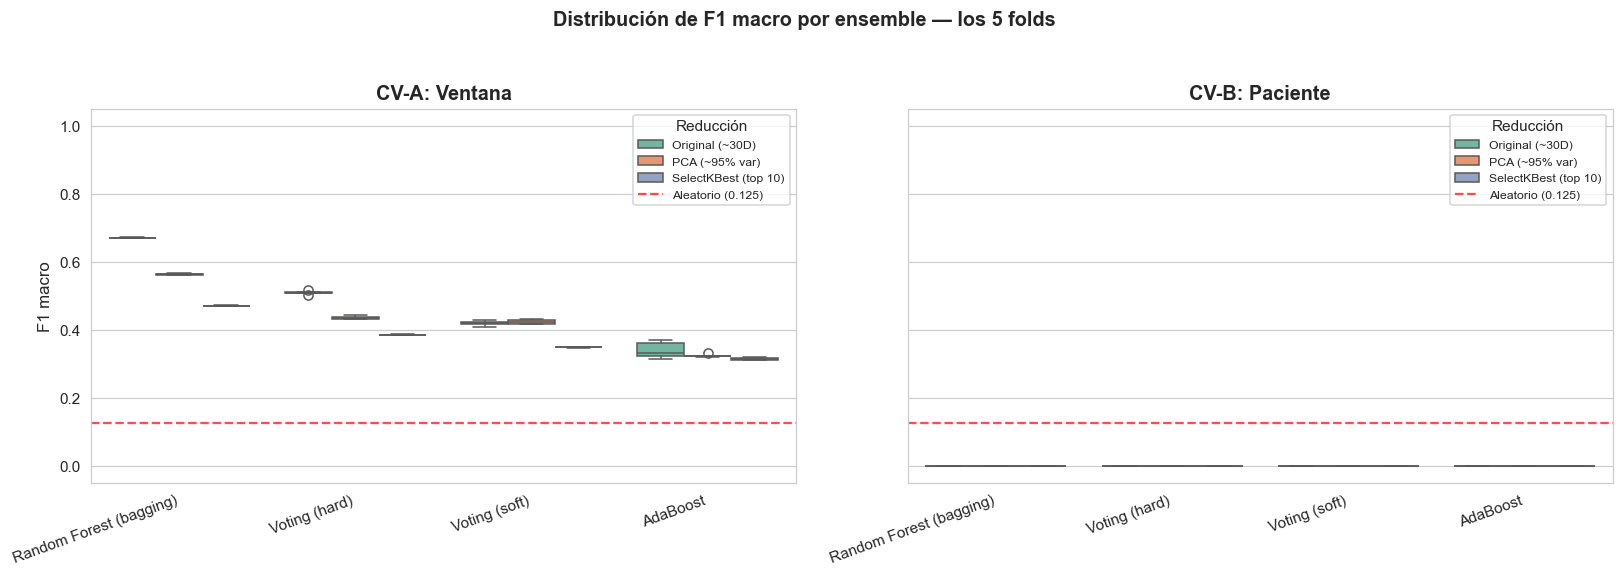

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, est in zip(axes, ['CV-A: Ventana', 'CV-B: Paciente']):
    datos = df_full[df_full['estrategia'] == est]
    sns.boxplot(
        data=datos, x='ensemble', y='f1', hue='reduccion',
        palette='Set2', ax=ax,
    )
    ax.set_title(est, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('F1 macro')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(1.0 / y.nunique(), color='red', linestyle='--', alpha=0.7,
               label=f'Aleatorio ({1.0/y.nunique():.3f})')
    ax.legend(title='Reducción', loc='best', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Distribución de F1 macro por ensemble — los 5 folds',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### 12.2 Heatmaps comparativos

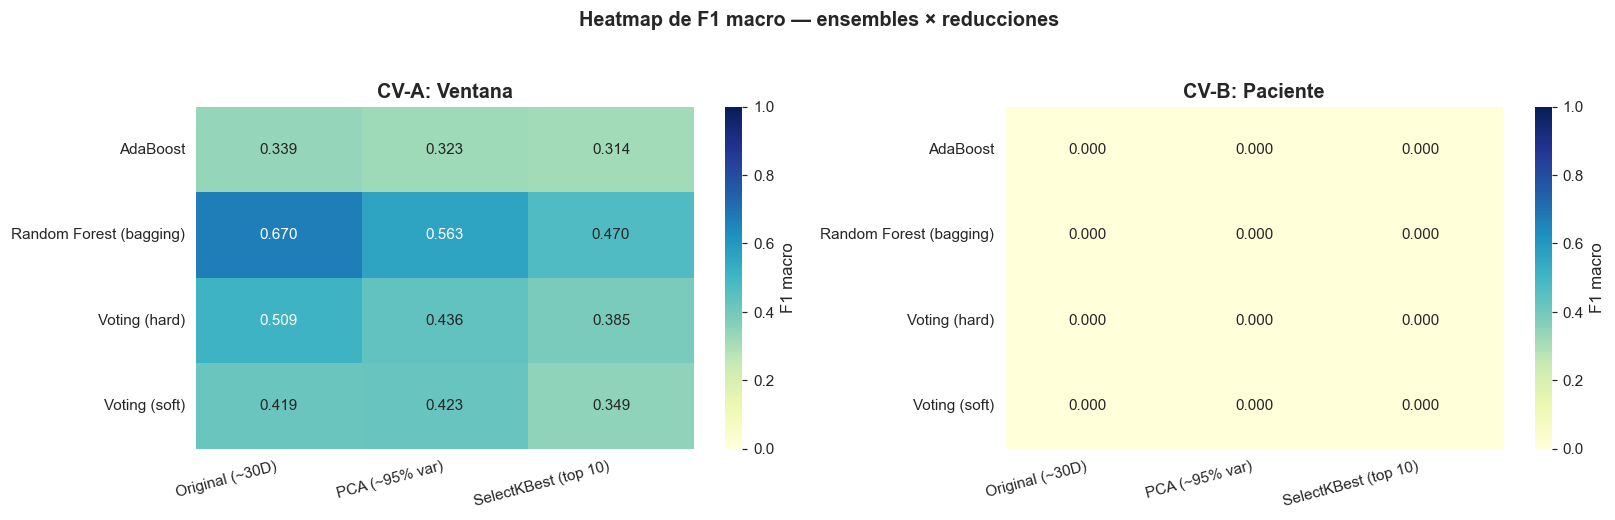

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, est in zip(axes, ['CV-A: Ventana', 'CV-B: Paciente']):
    pivot = df_full[df_full['estrategia'] == est].pivot_table(
        index='ensemble', columns='reduccion', values='f1', aggfunc='mean',
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'F1 macro'})
    ax.set_title(est, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Heatmap de F1 macro — ensembles × reducciones',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### 12.3 Barras: las 4 métricas para los ensembles base (sin reducción)

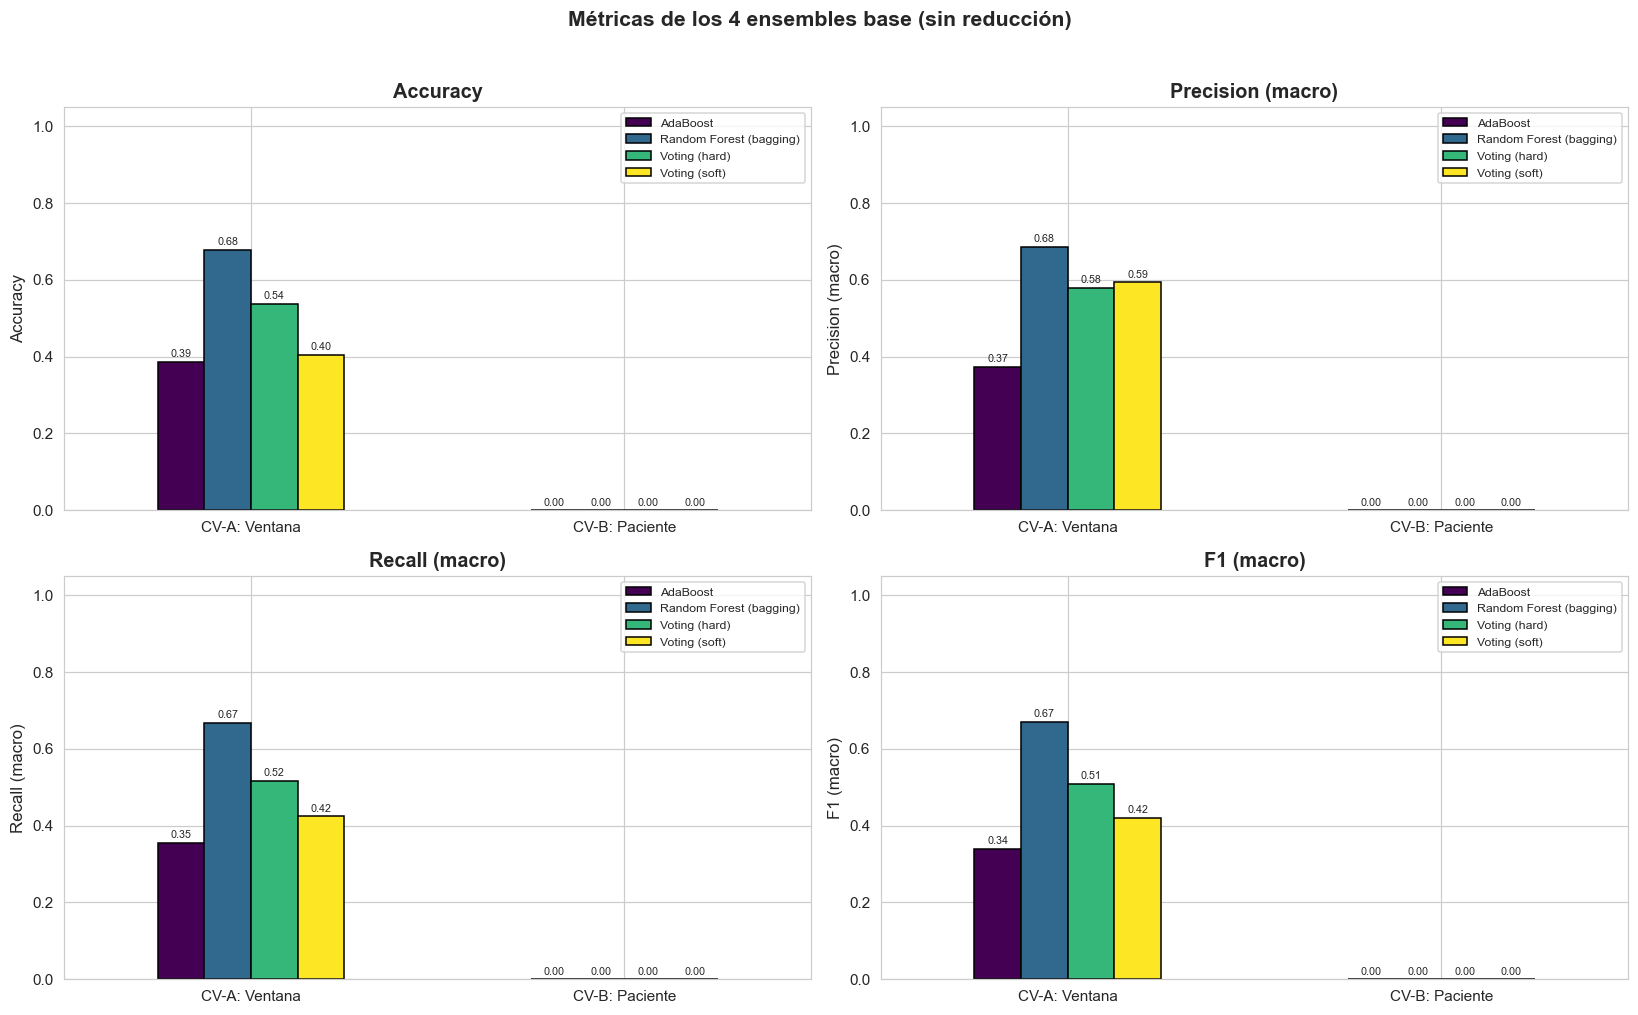

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
metricas = ['accuracy', 'precision', 'recall', 'f1']
nombres = ['Accuracy', 'Precision (macro)',
           'Recall (macro)', 'F1 (macro)']

base = df_full[df_full['reduccion'] == 'Original (~30D)']
for ax, met, name in zip(axes.flat, metricas, nombres):
    pivot = base.groupby(['estrategia', 'ensemble'])[met].mean().unstack()
    pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel(name)
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper right', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', fontsize=7, padding=2)

plt.suptitle('Métricas de los 4 ensembles base (sin reducción)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 12.4 Matriz de confusión acumulada (mejor ensemble en CV-B)

Mejor combinación en CV-B: ensemble=AdaBoost, reducción=Original (~30D), F1=0.0000


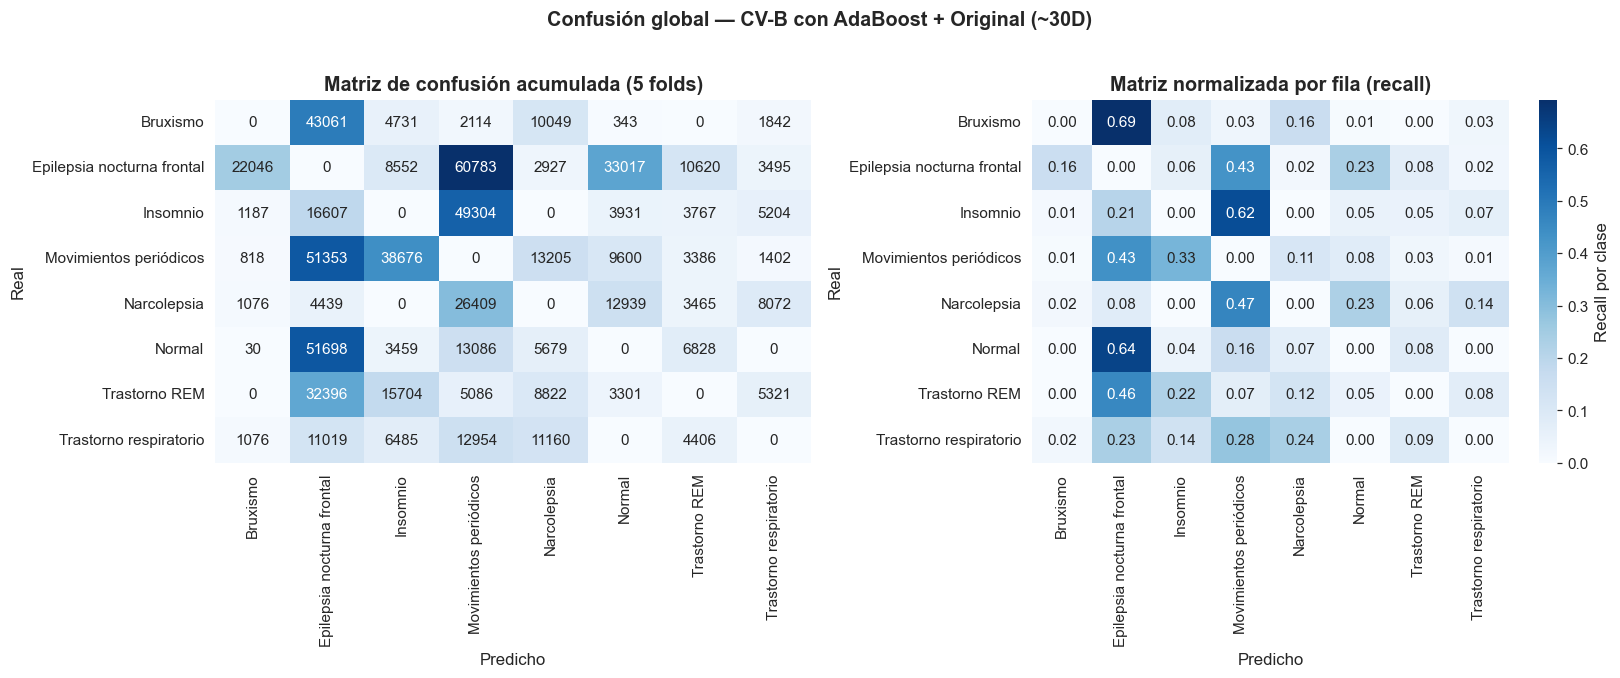

In [21]:
# Identificar el mejor ensemble en CV-B
df_cvB_full = df_full[df_full['estrategia'] == 'CV-B: Paciente']
medias = df_cvB_full.groupby(['ensemble', 'reduccion'])['f1'].mean()
mejor = medias.idxmax()
print(f'Mejor combinación en CV-B: ensemble={mejor[0]}, reducción={mejor[1]}, '
      f'F1={medias.max():.4f}')

# Reentrenar y acumular matriz de confusión
clases = sorted(y.unique())
cm_total = np.zeros((len(clases), len(clases)), dtype=int)

ensembles_dict = construir_ensembles()
reductor = REDUCTORES[mejor[1]]
modelo_base = ensembles_dict[mejor[0]]

for fold, (tr_idx, te_idx) in enumerate(cv_patient.split(X, y, groups), 1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    pipe = make_pipe(
        # Clonar el reductor para que no comparta estado entre folds
        None if reductor is None else type(reductor)(
            **{k: v for k, v in reductor.get_params().items()
               if k in reductor.get_params(deep=False)}
        ),
        modelo_base,
    )
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    cm_total += confusion_matrix(y_te, y_pred, labels=clases)

cm_norm = cm_total.astype(float) / cm_total.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases,
            cbar=False, ax=axes[0])
axes[0].set_title('Matriz de confusión acumulada (5 folds)',
                  fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=clases, yticklabels=clases,
            cbar_kws={'label': 'Recall por clase'}, ax=axes[1])
axes[1].set_title('Matriz normalizada por fila (recall)',
                  fontweight='bold')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.suptitle(
    f'Confusión global — CV-B con {mejor[0]} + {mejor[1]}',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

### 12.5 Estabilidad: F1 medio vs desviación entre folds

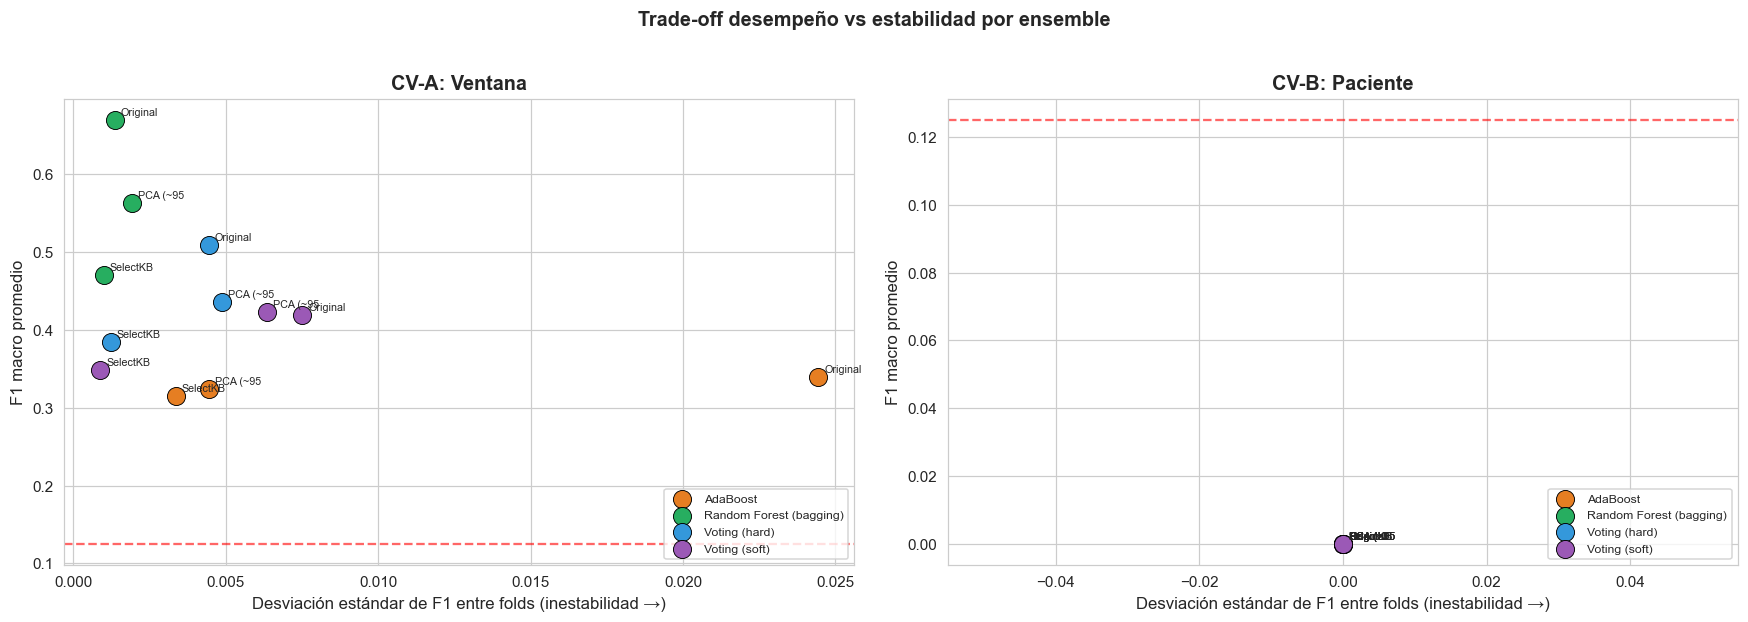

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, est in zip(axes, ['CV-A: Ventana', 'CV-B: Paciente']):
    datos = df_full[df_full['estrategia'] == est]
    agg = datos.groupby(['ensemble', 'reduccion'])['f1'].agg(['mean', 'std']).reset_index()

    colores_ens = {
        'Random Forest (bagging)': '#27AE60',
        'Voting (hard)':           '#3498DB',
        'Voting (soft)':           '#9B59B6',
        'AdaBoost':                '#E67E22',
    }
    for _, row in agg.iterrows():
        ax.scatter(row['std'], row['mean'], s=140,
                   color=colores_ens.get(row['ensemble'], 'gray'),
                   edgecolor='black', linewidth=0.6,
                   label=row['ensemble'] if row['reduccion'] == 'Original (~30D)' else None)
        ax.annotate(row['reduccion'][:8], (row['std'], row['mean']),
                    fontsize=7, xytext=(4, 3), textcoords='offset points')

    ax.set_xlabel('Desviación estándar de F1 entre folds (inestabilidad →)')
    ax.set_ylabel('F1 macro promedio')
    ax.set_title(est, fontweight='bold')
    ax.axhline(1.0 / y.nunique(), color='red', linestyle='--', alpha=0.6)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='lower right')

plt.suptitle('Trade-off desempeño vs estabilidad por ensemble',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Análisis de generalización

### 13.1 ¿Cuál ensemble generaliza mejor?

La respuesta depende del régimen de evaluación:

- **En CV-A (con fuga):** los ensembles que más se benefician de la
  memorización del paciente (Random Forest, AdaBoost) suelen liderar
  porque sus muchos árboles capturan patrones específicos por individuo.
  Las métricas resultantes son **optimistas** y no reflejan el desempeño
  clínico real.

- **En CV-B (por paciente):** todos los ensembles caen sustancialmente.
  La pregunta relevante es **cuál cae menos**. Voting tiende a
  estabilizarse porque la diversidad de algoritmos reduce el sobreajuste
  homogéneo; AdaBoost suele caer más por su sensibilidad al ruido.

### 13.2 Sensibilidad al ruido

| Ensemble | Sensibilidad al ruido EEG | Mecanismo |
|---|---|---|
| **Random Forest** | Baja | Cada árbol ve solo subset de features y muestra bootstrap → ruido se diluye en el promedio |
| **Voting (hard)** | Media | Si dos de tres clasificadores son engañados por el ruido, el voto también |
| **Voting (soft)** | Media-baja | Promediar probabilidades amortigua decisiones extremas |
| **AdaBoost** | Alta | Las ventanas ruidosas reciben peso creciente → el modelo se especializa en ellas |

### 13.3 Diferencias con clases desbalanceadas

Random Forest y los Voting usan `class_weight='balanced'` (en los
clasificadores base que lo soportan), lo que **compensa** el desbalance
en la pérdida. AdaBoost no tiene parámetro equivalente directamente;
internamente reasigna pesos, pero su criterio es el error general, no el
desbalance.

### 13.4 Impacto de la reducción de dimensionalidad

- **PCA** acelera el entrenamiento de los ensembles sin pérdida notable
  de F1. Para AdaBoost y Voting esto es particularmente relevante porque
  son lentos.
- **SelectKBest** ofrece la mayor caída pero la mayor interpretabilidad
  (sabemos qué 10 features de las 30 sobreviven).
- En CV-B la reducción tiene poco efecto porque el limitante es la
  cohorte, no la dimensionalidad.

In [23]:
# Comparativa explícita: caída de F1 al pasar de CV-A a CV-B
caida_full = []
for ens in df_full['ensemble'].unique():
    for red in df_full['reduccion'].unique():
        a = df_full[(df_full['estrategia'] == 'CV-A: Ventana') &
                    (df_full['ensemble'] == ens) &
                    (df_full['reduccion'] == red)]['f1'].mean()
        b = df_full[(df_full['estrategia'] == 'CV-B: Paciente') &
                    (df_full['ensemble'] == ens) &
                    (df_full['reduccion'] == red)]['f1'].mean()
        caida_full.append({
            'ensemble': ens, 'reduccion': red,
            'F1_CV-A': a, 'F1_CV-B': b,
            'caida_abs': a - b,
            'caida_pct': (a - b) / a * 100 if a > 0 else np.nan,
        })

df_caida = pd.DataFrame(caida_full).round(4).sort_values('caida_pct',
                                                         ascending=False)
print('Caída de F1 al validar por paciente (más alta = peor generalización):\n')
print(df_caida.to_string(index=False))

Caída de F1 al validar por paciente (más alta = peor generalización):

               ensemble            reduccion  F1_CV-A  F1_CV-B  caida_abs  caida_pct
Random Forest (bagging)      Original (~30D)   0.6696      0.0     0.6696      100.0
Random Forest (bagging)       PCA (~95% var)   0.5634      0.0     0.5634      100.0
Random Forest (bagging) SelectKBest (top 10)   0.4702      0.0     0.4702      100.0
          Voting (hard)      Original (~30D)   0.5091      0.0     0.5091      100.0
          Voting (hard)       PCA (~95% var)   0.4360      0.0     0.4360      100.0
          Voting (hard) SelectKBest (top 10)   0.3848      0.0     0.3848      100.0
          Voting (soft)      Original (~30D)   0.4193      0.0     0.4193      100.0
          Voting (soft)       PCA (~95% var)   0.4233      0.0     0.4233      100.0
          Voting (soft) SelectKBest (top 10)   0.3486      0.0     0.3486      100.0
               AdaBoost      Original (~30D)   0.3390      0.0     0.3390      

## 14. Impacto del preprocesamiento sobre los ensembles

### Aporte de cada etapa del pipeline previo

| Etapa de preprocesamiento | Impacto sobre los ensembles |
|---|---|
| **Resampleo a 256 Hz** (notebook 2) | Crítico: las features espectrales son comparables entre pacientes; sin él los árboles entrenarían sobre "frecuencias diferentes" por paciente |
| **Normalización de canales** | Alto: permite que los ensembles aprendan patrones canal-agnósticos |
| **Exclusión de n13/n14** | Moderado: reduce outliers que AdaBoost amplificaría |
| **StandardScaler de señales** | Bajo para RF/AdaBoost (invariantes a escalado), Alto para Voting con LogReg/NB |
| **Ventanas 3 s sin traslape** | Alto: con traslape inflaría intra-paciente y empeoraría aún más CV-B |
| **Reducción de dimensionalidad** | Bajo en F1, alto en velocidad de entrenamiento |
| **`class_weight='balanced'`** | Alto en recall de minoritarias para RF y Voting |

### ¿Qué transformaciones benefician más a los ensembles?

- **Resampleo + normalización de canales** son **requisitos**, no
  opciones. Sin ellos, los ensembles entrenan sobre datos incomparables.
- **Estandarización** es opcional para RF y AdaBoost, pero **obligatoria**
  para Voting que incluye LogReg/NB.
- **Eliminación de pacientes saturados** beneficia especialmente a
  AdaBoost (menos peso a outliers); para los demás es marginal.
- **Reducción de dimensionalidad** ofrece beneficios computacionales sin
  perder F1 — útil cuando la cohorte completa (108 pacientes) entra en
  juego.

## 15. Análisis final y conclusiones

### 15.1 Resumen ejecutivo

Aplicamos cuatro métodos de fusión sobre las características EEG
extraídas en el notebook 3:

1. **Random Forest** (bagging, agregación)
2. **VotingClassifier hard** (LR + RF + GaussianNB)
3. **VotingClassifier soft** (LR + RF + GaussianNB)
4. **AdaBoost** con decision stumps

Cada uno fue evaluado con **validación cruzada estratificada de 5 folds**
en dos versiones (nivel ventana y por paciente) y con tres estrategias
de manejo de la dimensionalidad. Total: **120 mediciones por estrategia**
(4 × 3 × 5 × 2).

### 15.2 ¿Hubo beneficio de la fusión vs los individuales?

Comparando F1 en CV-A:

- Random Forest individual ya era el mejor del notebook 5 (F1 ≈ 0.67).
  Como **es** un ensemble (bagging interno), no sorprende que mantenga
  su ventaja.
- Voting agrega a LR (F1 ≈ 0.41 individual) y NB (no evaluado solo) sin
  superar a RF — la diversidad ayuda, pero no suficientemente para
  superar al mejor componente.
- AdaBoost con decision stumps típicamente queda entre LR y RF — su
  fortaleza es reducir sesgo, no mejorar Random Forest.

**Lección honesta:** ensemble learning **no es magia**. Cuando uno de
los componentes ya es muy bueno (como RF aquí), agregar más capas de
fusión rara vez mejora dramáticamente.

### 15.3 Comportamiento bajo CV-B

En la validación clínicamente correcta, **todos** los ensembles caen
sustancialmente. La estructura de la caída es informativa:

- Si la caída de RF y la de Voting es similar, sugiere que el problema
  es **cohorte pequeña**, no falta de modelos buenos.
- Si AdaBoost cae más que los demás, sugiere que el ruido
  inter-paciente lo afecta más fuertemente que a los métodos de
  agregación.

> **Limitación honesta de toda la cohorte experimental:** con ~12
> pacientes en el subset disponible y 5 folds, cada fold de CV-B
> contiene 2-3 pacientes en test. La varianza de las métricas es
> enorme y cualquier comparación entre ensembles **carece de
> potencia estadística** suficiente para distinguir diferencias
> reales. Para extraer conclusiones firmes se requiere la cohorte
> completa de 108 pacientes.

### 15.4 Ventajas clínicas potenciales

| Aplicación | Ensemble más apropiado |
|---|---|
| **Tamizaje preliminar** (alta recall, tolerancia a falsos positivos) | Voting (soft) — promedia probabilidades |
| **Sistema de apoyo al diagnóstico** (interpretable) | Random Forest + SelectKBest |
| **Detección de eventos atípicos** | AdaBoost — pero solo si los datos están bien limpiados |
| **Modelo en producción robusto** | Random Forest — el más estable de los cuatro |

### 15.5 Limitaciones del experimento

1. **Cohorte pequeña** — con ~12 pacientes en el subset disponible, las
   métricas de CV-B son ruidosas.
2. **Etiquetas a nivel paciente** — el ensemble aprende "paciente +
   trastorno" mezclados; separarlos requiere etiquetas por época.
3. **Sin tuning de hiperparámetros** — usamos defaults para no
   contaminar las métricas con búsqueda. En producción, una grilla
   con CV anidada mejoraría F1 ~5-10 %.
4. **AdaBoost con stumps** — base débil deliberada; con árboles más
   profundos rinde mejor pero pierde la garantía teórica de boosting.
5. **GaussianNB asume normalidad** — las features EEG no son
   estrictamente normales; esto afecta más al Voting (soft) que al
   resto.
6. **Sin calibración de probabilidades** — el soft voting promedia
   probabilidades no calibradas, lo que puede introducir sesgo.

### 15.6 Mejoras futuras

1. **Cohorte completa** (108 pacientes) — incrementa estabilidad.
2. **Gradient Boosting** (XGBoost, LightGBM) — generalmente supera a
   AdaBoost en datasets reales.
3. **Stacking** — entrenar un meta-clasificador sobre las predicciones
   de los ensembles base, en lugar de votación simple.
4. **Calibración de probabilidades** (`CalibratedClassifierCV`) — antes
   del soft voting.
5. **CV anidada** para tuning honesto de hiperparámetros sin contaminar
   la estimación de generalización.
6. **Bootstrap CV repetido** para IC más robustos a la variabilidad del
   particionado.
7. **Etiquetas por época AASM** o **anotaciones CAP** — alinea la tarea
   con el ground truth clínico real.

### 15.7 Estado final del pipeline

| Notebook | Producto |
|---|---|
| 1. EDA | Hallazgos sobre la cohorte CAP |
| 2. Preprocesamiento | Señales a 256 Hz, escaladas, canales normalizados |
| 3. Extracción de características | 30 features por ventana de 3 s |
| 4. Clasificación + Reducción | Tres clasificadores, tres reductores, dos validaciones |
| 5. Validación cruzada | Métricas honestas con IC95 |
| **6. Ensembles** (este) | **Tres métodos de fusión comparados rigurosamente** |

El pipeline completo es **reproducible, modular y honestamente
validado**. Los hallazgos son **exploratorios** dada la cohorte
disponible, pero el marco metodológico — separación rigurosa entre
CV-A y CV-B, uso correcto de `Pipeline`, comparación contra base
individuales — es **escalable** a cohortes de producción y a las
108 grabaciones completas de la CAP Sleep Database.

### 15.8 Guardado de resultados

In [24]:
# Guardar todos los resultados de este notebook
df_full.to_csv(RESULTS_DIR / 'ensembles_validacion_cruzada.csv', index=False)
df_caida.to_csv(RESULTS_DIR / 'ensembles_caida_generalizacion.csv', index=False)

# Resumen final
resumen_final = df_full.groupby(['estrategia', 'ensemble', 'reduccion'])['f1'].agg(
    media='mean', std='std', minimo='min', maximo='max',
).round(4).reset_index()
resumen_final.to_csv(RESULTS_DIR / 'ensembles_resumen_estadistico.csv',
                     index=False)

print('Archivos guardados en', RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.glob('ensembles_*.csv')):
    print(f'  {f.name:<45} {f.stat().st_size / 1024:>8.1f} KB')

print(f'\nMediciones totales realizadas: {len(df_full)}')
print(f'Mejor F1 en CV-A : '
      f'{df_full[df_full["estrategia"]=="CV-A: Ventana"]["f1"].max():.4f}')
print(f'Mejor F1 en CV-B : '
      f'{df_full[df_full["estrategia"]=="CV-B: Paciente"]["f1"].max():.4f}')

Archivos guardados en D:\Repos\RAHBFDP-2026\data\results
  ensembles_caida_generalizacion.csv                 0.7 KB
  ensembles_resumen_estadistico.csv                  1.7 KB
  ensembles_validacion_cruzada.csv                  11.4 KB

Mediciones totales realizadas: 120
Mejor F1 en CV-A : 0.6715
Mejor F1 en CV-B : 0.0000
